# CO$_2$ - extend the seasonality change principal components

Extend the seasonality change's principal components back in time.
For CO$_2$, we do this by using a regression against
temperatures and global-mean concentrations.

## Imports

In [2]:
from collections.abc import Iterator
from contextlib import contextmanager
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import numpy as np
import openscm_units
import pint
import pint_xarray
import xarray as xr
from attrs import evolve
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.config
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.regressors
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [3]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

Quantity = pint.get_application_registry().Quantity  # type: ignore

In [4]:
opscm_reg = pint_xarray.setup_registry(openscm_units.unit_registry)
QuantityOSCM = opscm_reg.Quantity

## Define branch this notebook belongs to

In [5]:
step: str = "calculate_co2_monthly_fifteen_degree_pieces"

## Parameters

In [6]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "only"  # config ID to select for this branch

In [7]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "only"


## Load config

In [8]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

config_retrieve_misc = get_config_for_step_id(config=config, step="retrieve_misc_data", step_config_id="only")

## Action

### Helper functions

In [9]:
@contextmanager
def axes_vertical_split(
    ncols: int = 2,
) -> Iterator[tuple[matplotlib.axes.Axes, matplotlib.axes.Axes]]:
    """Get two split axes, formatting after exiting the context"""
    fig, axes = plt.subplots(ncols=ncols)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    yield (axes[0], axes[1])

    plt.tight_layout()
    plt.show()

### Load data

In [10]:
global_annual_mean: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.global_annual_mean_allyears_file
).pint.quantify()
global_annual_mean

Magnitude,[280.47743367138463 280.43743367138467 280.38743367138466 ... 415.12597139417943 417.32025724171285 419.6866820727719]
Units,ppm


In [11]:
hadcrut_temperatures = xr.load_dataset(
    config_retrieve_misc.hadcrut5.raw_dir / config_retrieve_misc.hadcrut5.download_url.url.split("/")[-1]
)["tas_mean"].pint.quantify()
hadcrut_temperatures = (
    local.xarray_time.convert_time_to_year_month(hadcrut_temperatures)
    .sel(month=7)
    .drop_vars(["month", "latitude", "longitude", "realization"])
)
hadcrut_temperatures

Magnitude,[-0.4177113920453289 -0.2333498002270332 -0.22939907229660023 -0.2703544420795381 -0.2915208434909786 -0.29691675522721006 -0.32035371346936936 -0.4672300416567563 -0.3887656797740938 -0.28126517136832124 -0.3901651776544678 -0.42911293405471396 -0.5363693614995809 -0.3442440738288287 -0.4654650750936489 -0.33248133453493867 -0.3412875011472423 -0.35699411690773614 -0.3518271568140321 -0.3165919523221899 -0.32792752017861304 -0.3685627535298552 -0.3281105765675268 -0.3412968978400663 -0.37325118715564926 -0.3756259431757351 -0.42410991091052475 -0.10110883919847106 -0.011315191745013052 -0.30363432225563847 -0.31583206233663524 -0.232245526185631 -0.29553008307253237 -0.34647440769427634 -0.4923200687129247 -0.47112357667991345 -0.4209036113305654 -0.49878576473980574 -0.37937888661792685 -0.24989555203981034 -0.5068581616547795 -0.4013149453771571 -0.5075585352398684 -0.49461922674162073 -0.4837639304154443 -0.4487516068094253 -0.28400726706776686 -0.25980015667457923 -0.4857921231739396 -0.3554336528363127 -0.23449390065388898 -0.2934102535581404 -0.43895653537855805 -0.5332871003864723 -0.5975110615883662 -0.40779322540392726 -0.31910878901549994 -0.504076295391818 -0.5138196995407287 -0.5356871574747741 -0.530909499684868 -0.5390790388155751 -0.4755386422593995 -0.4670110854075412 -0.2624365760892116 -0.19167219280336045 -0.4200231537926108 -0.5428196847609768 -0.4243641002611059 -0.3252890626289348 -0.2983550727553379 -0.2404443516394132 -0.33901369998123143 -0.31768186776829427 -0.31180170238215527 -0.28214198701224613 -0.12255500349449744 -0.2291136002985501 -0.2064658059913023 -0.39244303047636925 -0.17680541614245168 -0.10339767711434497 -0.14546171122031562 -0.3223444164633408 -0.17433684876984767 -0.20605923969194478 -0.16952095068614528 -0.019198946531133607 -0.012200737394096318 -0.04079720220041782 0.07593581835997043 0.03812930054538256 0.001406067743880726 0.006421582366325944 0.14410513488699267 0.04308835279543335 -0.11881461314200102 -0.09120560856601351 -0.12466126636418672 -0.1438022196749041 -0.22662180987313607 -0.061153960042037145 0.015354547820030118 0.07763074993652623 -0.11675023026486858 -0.19730994004778957 -0.26316561666075494 -0.03533491593747076 -0.01763256179123164 -0.04800481443215007 -0.11545958388142852 -0.0199997677069081 -0.06404271765191233 -0.03681061262791293 -0.30586153677877165 -0.20442047173485867 -0.14889760881402803 -0.11753929563190729 -0.16864756022175545 -0.03138624157150907 -0.08506408695225576 -0.205889043505964 -0.09379131434288407 0.04995016004664153 -0.1725265629152332 -0.1107542154945977 -0.21583689672390435 0.10308849605531217 0.005255971345943811 0.09085813686307134 0.19607204082641672 0.25001204011887623 0.034268282224556114 0.22380983762374038 0.04799351675081274 0.04972974041830516 0.0956869794789133 0.24302640412720267 0.2821517106815492 0.1792502926203305 0.36058237851525504 0.3388965345269557 0.12489683546542665 0.16570718635485235 0.23354978353054195 0.37686614556063747 0.27668938903735607 0.4223085172599136 0.5773416864512658 0.32448497409398414 0.33108475622533623 0.48928034491093264 0.543466493713195 0.5441701513856901 0.46737072630072535 0.606862513591056 0.5725526875945842 0.5917013213719408 0.4656498416451012 0.5967816369361943 0.6803713919071717 0.5376977451370432 0.5776070548011991 0.6235753532227446 0.6728716513059096 0.8251144324080744 0.9329270734080012 0.8451742516874354 0.7626540368876639 0.8910725811953256 0.9229205298862512 0.7619055613640165 0.8013053238075507 1.1003127098794483 1.1776936501438842]
Units,kelvin


In [12]:
local.dependencies.save_dependency_into_db(
    db=config.dependency_db,
    gas=config_step.gas,
    dependency_short_name=config_retrieve_misc.hadcrut5.source_info.short_name,
)

In [13]:
seasonality_change_eofs_obs_network = xr.load_dataset(
    config_step.observational_network_seasonality_change_eofs_file
).pint.quantify()
seasonality_change_eofs_obs_network

Magnitude,[[[0.004200787188956484 -0.010149144448462287 -0.014555453750241702 -0.008518519591661078 -0.0038084449949983556 0.0015516709807955693 0.004011410852796488 0.0066049569161054575 0.005455775550594557 0.0038370153756936832 0.0033217633604819647 0.008048412087736516] [-0.003813357863191492 -0.015736342919797267 -0.015416438932829193 -0.005512150461818064 0.0009368741028855893 0.00705632623009416 0.008231968943754596 0.009378428237683771 0.009218433325127137 0.007131926377056381 0.0018463456642353385 -0.0033217612048648563] [-0.012723183583927041 -0.030015453578080133 -0.025684332296317548 -0.010315371668997242 -0.0010074966620193422 0.006882223122370703 0.014211362092602584 0.0224188240780778 0.02351006597529157 0.016888995867390837 0.0038743764884393277 -0.008039811397586055] [0.0007370490716892465 -0.017597452288442225 -0.017063251360386757 -0.008991960486357215 -0.0029845085335313756 -0.0004626650506136561 0.005225324365946439 0.015214897787388758 0.01524183703627152 0.010665375777428774 0.0015370492034393617 -0.0015215101589910343] [0.010202266632504361 -0.010800206632082886 -0.011558184180062644 -0.009210205947219038 -0.0023528224597277017 -0.0026438218443953993 0.003944670545643293 0.01317870486958088 0.009456188015833733 0.004239353692484787 -0.0006499210507010432 -0.0038059335666004632] [0.04632553482317954 0.029488708054586275 0.019598313416887354 0.0007800413398017221 -0.015780861148305857 -0.02827428598026653 -0.022279935844817786 -0.016011011224883038 -0.008984280409509379 -0.004651575425084061 -0.0038102239025934606 0.0035995881363072913] [0.06379741041969815 0.05501880493276163 0.03734811895557013 0.04020622369694015 0.017795935549551542 -0.03562162969243313 -0.04915813014876787 -0.05039283339862896 -0.052481887009473024 -0.04549763894918835 -0.005728793389079505 0.024714516303831785] [0.07118287403135662 0.05553116323103778 0.04325891524130703 0.061617883372439196 0.018217594479479637 -0.06659171813188253 -0.06722738551795744 -0.039863080089778985 -0.046812891968343665 -0.052948030697668624 -0.012462701937959004 0.036097486156288966] [0.12182513963346352 0.08762936319869978 0.04658080791152114 0.009308694648401507 -0.07275208290404085 -0.1832926733709645 -0.18830284107327025 -0.08556203131462699 0.006848925088064385 0.0648089153715204 0.08444451622328954 0.10846341823053145] [0.1961220169695092 0.17977863424293714 0.13308041965230769 0.03377719450459981 -0.0936991937878084 -0.24096428211757012 -0.32187345139180995 -0.24063146122865528 -0.09263687482193474 0.07032097856082614 0.18665744724296696 0.19006862406736472] [0.1359161249571294 0.1241778144862185 0.09536034021346418 0.06514735951345428 -0.0018692306765028452 -0.1702972354581949 -0.31252810445932316 -0.20595301434906468 -0.045313307251242683 0.04274468124382565 0.12457144699702265 0.14804339012981396] [0.07357219576595192 0.09634071762514099 0.10374128219273218 0.09284978310532996 0.038141070984567926 -0.08568009369276812 -0.20029543562732988 -0.19107522886994588 -0.09787247237255348 -0.005934616002685327 0.08694702678150247 0.08926615886618836]]]
Units,ppm
Magnitude,[[-8.448389309470329] [-7.20778036595789] [-7.641582802336676] [-6.111287485012081] [-7.786569367487797] [-6.176694029405333] [-8.572251564164931] [-4.467031044686843] [-3.892265412839174] [-1.9754485645210944] [-3.2702878078143454] [-2.8119766597292273] [-2.04562912294732] [-1.669530821099349] [0.20864479234105024] [-3.4306823245505202] [-0.6006219761581261] [-0.8621346517702358] [2.14966642238909] [-0.14840245724376344] [1.8268156465334235] [1.1281325057998945] [1.3107664021933685] [0.6179007061166677] [1.1289057932124835] [0.4710089633358845] [1.773690166069412] [4.519284282471136] [3.523380881180639] [3.9612643362080333] [6.986235730409714] [8.012609931334143] [2.515315451797805] [4.394308643350135] [2.9263279059968865] [5.089107369049445] [4.280080218172309] [1.6923265372244087] [2.647520113495585] [5.513469277051585] [2.528839946309975] [3.858921499441288] [4.054042245710685]]
Uni

### Define some important constants

In [14]:
if not config.ci:
    out_years = np.arange(1, seasonality_change_eofs_obs_network["year"].max() + 1)

else:
    out_years = np.arange(1750, seasonality_change_eofs_obs_network["year"].max() + 1)

out_years

array([   1,    2,    3, ..., 2021, 2022, 2023])

In [15]:
obs_network_years = seasonality_change_eofs_obs_network["year"]
obs_network_years

<xarray.DataArray 'year' (year: 43)> Size: 344B
array([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023])
Coordinates:
  * year     (year) int64 344B 1981 1982 1983 1984 1985 ... 2020 2021 2022 2023

In [16]:
use_extensions_years = np.setdiff1d(out_years, obs_network_years)
use_extensions_years

array([   1,    2,    3, ..., 1978, 1979, 1980])

### Extend PC zero

(Zero-indexing, hence this is the first PC)

This happens in a few steps.

In [17]:
# Quick assertion that things are as expected
exp_n_eofs = 1
if len(seasonality_change_eofs_obs_network["eof"]) != exp_n_eofs:
    raise AssertionError("Rethink")

#### Use a regression against concentrations and temperatures to fill in the gap

There is a gap between the observational network period
and the optimised ice core period.
We fill this using a regression against global-mean concentrations and temperatures.

In [18]:
regressor = local.seasonality.CO2SeasonalityChangeRegression()
regressor

CO2SeasonalityChangeRegression(ref_period_start=1850, ref_period_end=1880, norm_period_start=2000, norm_period_end=2010, temperature_smoothing_window=15, temperature_smoothing_min_values=5, regression_result=None)

In [19]:
regression_timeseries = regressor.get_composite(
    temperatures=hadcrut_temperatures, concentrations=global_annual_mean
)
regression_timeseries

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/default/lib/python3.11/site-packages/xarray/core/rolling.py:600: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  values = func(


Magnitude,[0.001216780593402657 -0.0006555237564391155 0.000893416447284832 -0.0005250171845835773 -0.002548135841081156 -0.006543024356865578 -0.0060964938619286575 -0.0079494545328944 -0.006041233161242179 -0.007732357871953296 -0.009787559213461305 -0.010967085442444343 -0.011094805540242843 -0.011333692744721482 -0.011876393997165903 -0.008833217879807322 -0.007526567563763832 -0.008858519858019338 -0.008132118507807755 -0.007583763137376829 0.0013105150675995008 0.008310129006664418 0.011993810005385594 0.012873702159110729 0.01552407943096934 0.017278143200369675 0.01794365115482984 0.014999551267223568 0.012733286022190921 0.012311691551089925 0.009530967569841307 0.009470763591402065 0.012763976688346723 0.010881803446600676 0.012167681736281478 0.0045517234798423635 -0.004728022221130038 -0.007737978008887585 -0.009736013549462024 -0.010063626358282264 -0.008499541502858235 -0.01072865205190487 -0.006983760087376161 -0.0010150386210701517 0.0025768541781316626 0.004707934244983985 0.002065217609003373 -0.00499633558642058 -0.0020349712707488834 0.0006081847860629967 0.001457056109320047 0.0017746330380599999 0.0013247566298703103 0.00018608745977898456 -0.005071393099778836 -0.009444949577280135 -0.008311625839473136 -0.005375268593957456 -0.003710688525295787 -0.006087391046558687 -0.007937102308239376 -0.004633223055897058 0.002754848452589365 0.0062654452730151 0.008931522726269393 0.013889085425476975 0.019772938198713806 0.02644850139448126 0.033843589686490004 0.0455247182410118 0.05321324772109668 0.06106239466543044 0.058873984857355996 0.06051531612282662 0.06999398738462494 0.08163414228704059 0.08539856925646708 0.09064659851476518 0.09415675769202274 0.0972520096960188 0.10699502368461403 0.11638531627015794 0.12500027473916078 0.13638127157825433 0.1424560188136691 0.1506229141675442 0.1584914636406361 0.17567574724800772 0.1837244013259883 0.18520898992913257 0.18862229518320445 0.19598554373591842 0.19832860221148496 0.19911547117873168 0.20350678677103307 0.20522455627752798 0.20919558551881945 0.20818470676432188 0.20118315456060723 0.1931685755630134 0.1933585187644137 0.1940743611886023 0.18960619954377916 0.18623798088913196 0.19079947172824904 0.19350715306097996 0.19812667979947046 0.1949681799422417 0.19767002481944446 0.19706528151710603 0.19601729165176485 0.19123468582783545 0.19713092685176165 0.2040173787416587 0.20923303957864295 0.2107168047502079 0.21658138632888738 0.21606241199319692 0.22010657521016536 0.2172927628521611 0.22739738821581143 0.23333021776744342 0.2524195479665066 0.272219866736142 0.2925518796548015 0.3041169473281255 0.32532165608671715 0.33494169909678906 0.3470419958365908 0.3661726375478583 0.38723498457588557 0.40447312718299844 0.42160464948384246 0.4497051173606648 0.48287409286558636 0.49233994326977704 0.5081110535008664 0.5250049727432339 0.5482899028404356 0.5591930164716569 0.5848761522458548 0.609921506645186 0.6288731563900436 0.6471081248674362 0.6752755561480985 0.703476732718928 0.729047517148761 0.7523095826634473 0.784525988344863 0.8102676639882496 0.8446680929779998 0.8726341204378707 0.9086558982347145 0.9453201745658963 0.9732367050319912 0.9975383730291576 1.0175406454776765 1.0510549253761836 1.0984608833779395 1.138483864406333 1.1778480335444763 1.2106641021756432 1.2565073935379396 1.3012328050002515 1.3308436766605776 1.3659682739655925 1.4377488396663618 1.496782115815205 1.5306630474614036 1.5790253024425458 1.6273547491202813 1.6734932761337298 1.7189305465225881 1.7530789389616004]
Units,dimensionless


In [20]:
pc0_obs_network = seasonality_change_eofs_obs_network["principal-components"].sel(eof=0)
pc0_obs_network

Magnitude,[-8.448389309470329 -7.20778036595789 -7.641582802336676 -6.111287485012081 -7.786569367487797 -6.176694029405333 -8.572251564164931 -4.467031044686843 -3.892265412839174 -1.9754485645210944 -3.2702878078143454 -2.8119766597292273 -2.04562912294732 -1.669530821099349 0.20864479234105024 -3.4306823245505202 -0.6006219761581261 -0.8621346517702358 2.14966642238909 -0.14840245724376344 1.8268156465334235 1.1281325057998945 1.3107664021933685 0.6179007061166677 1.1289057932124835 0.4710089633358845 1.773690166069412 4.519284282471136 3.523380881180639 3.9612643362080333 6.986235730409714 8.012609931334143 2.515315451797805 4.394308643350135 2.9263279059968865 5.089107369049445 4.280080218172309 1.6923265372244087 2.647520113495585 5.513469277051585 2.528839946309975 3.858921499441288 4.054042245710685]
Units,dimensionless


In [21]:
regression_timeseries_same_years = regression_timeseries.sel(year=pc0_obs_network["year"])
regression_timeseries_same_years

Magnitude,[0.40447312718299844 0.42160464948384246 0.4497051173606648 0.48287409286558636 0.49233994326977704 0.5081110535008664 0.5250049727432339 0.5482899028404356 0.5591930164716569 0.5848761522458548 0.609921506645186 0.6288731563900436 0.6471081248674362 0.6752755561480985 0.703476732718928 0.729047517148761 0.7523095826634473 0.784525988344863 0.8102676639882496 0.8446680929779998 0.8726341204378707 0.9086558982347145 0.9453201745658963 0.9732367050319912 0.9975383730291576 1.0175406454776765 1.0510549253761836 1.0984608833779395 1.138483864406333 1.1778480335444763 1.2106641021756432 1.2565073935379396 1.3012328050002515 1.3308436766605776 1.3659682739655925 1.4377488396663618 1.496782115815205 1.5306630474614036 1.5790253024425458 1.6273547491202813 1.6734932761337298 1.7189305465225881 1.7530789389616004]
Units,dimensionless


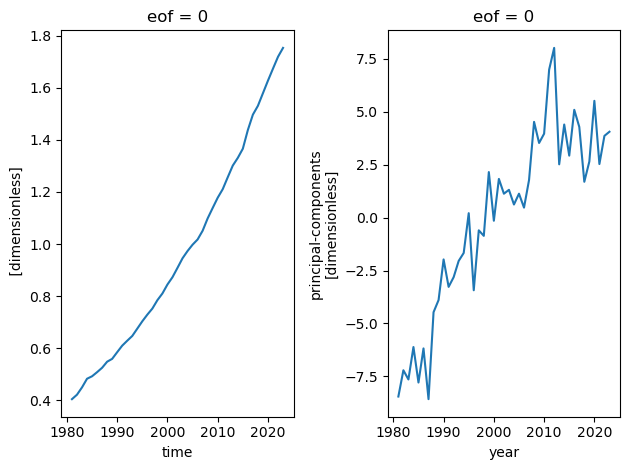

In [22]:
with axes_vertical_split() as axes:
    regression_timeseries_same_years.pint.dequantify().plot(ax=axes[0])
    pc0_obs_network.plot(ax=axes[1])

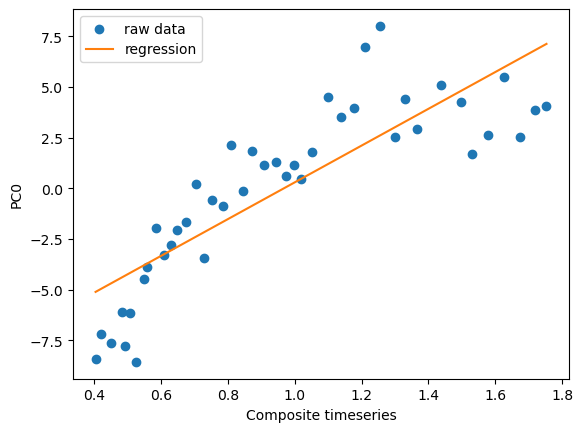

In [23]:
x = QuantityOSCM(
    regression_timeseries_same_years.data.m,
    str(regression_timeseries_same_years.data.units),
)
A = np.vstack([x.m, np.ones(x.size)]).T
y = QuantityOSCM(pc0_obs_network.data.m, str(pc0_obs_network.data.units))

res = np.linalg.lstsq(A, y.m, rcond=None)
m, c = res[0]
m = QuantityOSCM(m, (y / x).units)
c = QuantityOSCM(c, y.units)

latitudinal_gradient_pc0_composite_regression = local.regressors.LinearRegressionResult(m=m, c=c)

fig, ax = plt.subplots()
ax.scatter(x.m, y.m, label="raw data")
ax.plot(x.m, (m * x + c).m, color="tab:orange", label="regression")
ax.set_ylabel("PC0")
ax.set_xlabel("Composite timeseries")
ax.legend()

In [24]:
regressor_incl_result = evolve(regressor, regression_result=latitudinal_gradient_pc0_composite_regression)
regressor_incl_result

CO2SeasonalityChangeRegression(ref_period_start=1850, ref_period_end=1880, norm_period_start=2000, norm_period_end=2010, temperature_smoothing_window=15, temperature_smoothing_min_values=5, regression_result=LinearRegressionResult(m=<Quantity(9.076883630347558, 'dimensionless')>, c=<Quantity(-8.78663711284472, 'dimensionless')>))

Extend the composite back to year 1, assuming constant before 1850.

In [25]:
composite_extension_years = np.union1d(
    np.setdiff1d(out_years, pc0_obs_network["year"]),
    regression_timeseries["year"],
)
composite_extension_years

array([   1,    2,    3, ..., 2021, 2022, 2023])

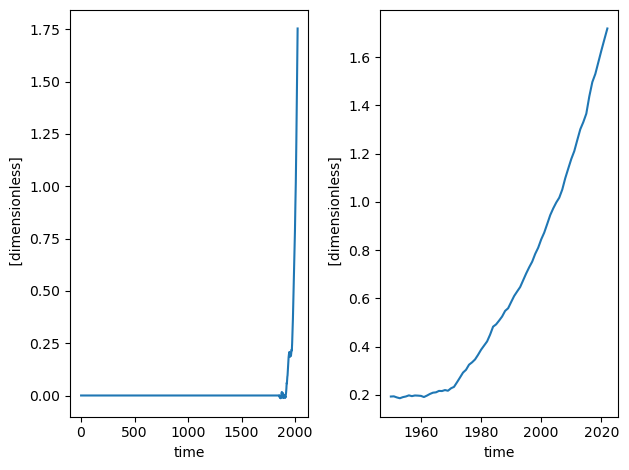

<xarray.DataArray (year: 2023)> Size: 16kB
array([1.21678059e-03, 1.21678059e-03, 1.21678059e-03, ...,
       1.67349328e+00, 1.71893055e+00, 1.75307894e+00])
Coordinates:
  * year     (year) int64 16kB 1 2 3 4 5 6 7 ... 2018 2019 2020 2021 2022 2023
Attributes:
    units:    dimensionless

In [26]:
regression_timeseries_extended = regression_timeseries.copy()
regression_timeseries_extended = regression_timeseries_extended.pint.dequantify().interp(
    year=composite_extension_years,
    kwargs={"fill_value": regression_timeseries.data[0].m},
)

with axes_vertical_split() as axes:
    regression_timeseries_extended.plot(ax=axes[0])  # type: ignore
    regression_timeseries_extended.sel(year=range(1950, 2023)).plot(ax=axes[1])  # type: ignore

regression_timeseries_extended

In [27]:
years_to_fill_with_regression = np.setdiff1d(
    regression_timeseries_extended["year"],
    pc0_obs_network["year"],
)

years_to_fill_with_regression

array([   1,    2,    3, ..., 1978, 1979, 1980])

In [28]:
pc0_regression_extended = (
    m
    * regression_timeseries_extended.sel(year=years_to_fill_with_regression).pint.quantify(
        unit_registry=opscm_reg
    )
    + c
)
pc0_regression_extended = pc0_regression_extended.assign_coords(eof=0)
pc0_regression_extended

Magnitude,[-8.775592536994738 -8.775592536994738 -8.775592536994738 ... -5.636577301792423 -5.462930693205375 -5.271750220249975]
Units,dimensionless


#### Concatenate the pieces of PC0

Join:

- extended based on regression with emissions
- raw values derived from the observational network

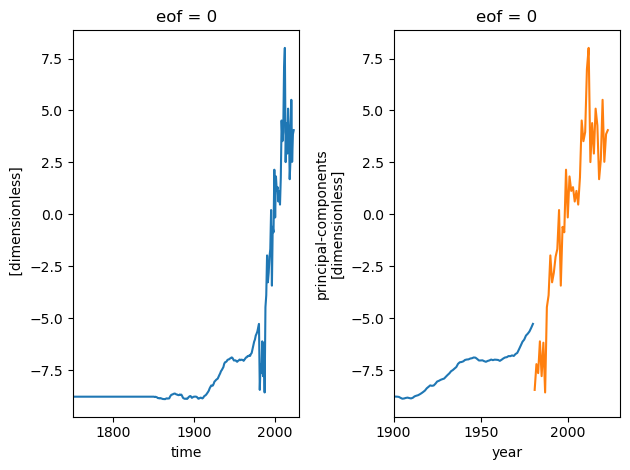

Magnitude,[-8.775592536994738 -8.775592536994738 -8.775592536994738 ... 2.528839946309975 3.858921499441288 4.054042245710685]
Units,dimensionless


In [29]:
allyears_pc0 = xr.concat(
    [
        pc0_regression_extended,
        pc0_obs_network,
    ],
    "year",
)

with axes_vertical_split() as axes:
    allyears_pc0.plot(ax=axes[0])
    axes[0].set_xlim((1750, 2030))

    pc0_regression_extended.plot(ax=axes[1])
    pc0_obs_network.plot(ax=axes[1])
    axes[1].set_xlim((1900, 2030))

allyears_pc0

### Join the PCs back together

In [30]:
allyears_pcs = xr.concat([allyears_pc0], "eof").pint.dequantify().pint.quantify()
allyears_pcs

Magnitude,[[-8.775592536994738 -8.775592536994738 -8.775592536994738 ... 2.528839946309975 3.858921499441288 4.054042245710685]]
Units,dimensionless


### Join PCs and EOFs back together

In [31]:
allyears_pcs.name = "principal-components"
out = xr.merge([allyears_pcs, seasonality_change_eofs_obs_network["eofs"]])
out

Magnitude,[[-8.775592536994738 -8.775592536994738 -8.775592536994738 ... 2.528839946309975 3.858921499441288 4.054042245710685]]
Units,dimensionless
Magnitude,[[[0.004200787188956484 -0.010149144448462287 -0.014555453750241702 -0.008518519591661078 -0.0038084449949983556 0.0015516709807955693 0.004011410852796488 0.0066049569161054575 0.005455775550594557 0.0038370153756936832 0.0033217633604819647 0.008048412087736516] [-0.003813357863191492 -0.015736342919797267 -0.015416438932829193 -0.005512150461818064 0.0009368741028855893 0.00705632623009416 0.008231968943754596 0.009378428237683771 0.009218433325127137 0.007131926377056381 0.0018463456642353385 -0.0033217612048648563] [-0.012723183583927041 -0.030015453578080133 -0.025684332296317548 -0.010315371668997242 -0.0010074966620193422 0.006882223122370703 0.014211362092602584 0.0224188240780778 0.02351006597529157 0.016888995867390837 0.0038743764884393277 -0.008039811397586055] [0.0007370490716892465 -0.017597452288442225 -0.017063251360386757 -0.008991960486357215 -0.0029845085335313756 -0.0004626650506136561 0.005225324365946439 0.015214897787388758 0.01524183703627152 0.010665375777428774 0.0015370492034393617 -0.0015215101589910343] [0.010202266632504361 -0.010800206632082886 -0.011558184180062644 -0.009210205947219038 -0.0023528224597277017 -0.0026438218443953993 0.003944670545643293 0.01317870486958088 0.009456188015833733 0.004239353692484787 -0.0006499210507010432 -0.0038059335666004632] [0.04632553482317954 0.029488708054586275 0.019598313416887354 0.0007800413398017221 -0.015780861148305857 -0.02827428598026653 -0.022279935844817786 -0.016011011224883038 -0.008984280409509379 -0.004651575425084061 -0.0038102239025934606 0.0035995881363072913] [0.06379741041969815 0.05501880493276163 0.03734811895557013 0.04020622369694015 0.017795935549551542 -0.03562162969243313 -0.04915813014876787 -0.05039283339862896 -0.052481887009473024 -0.04549763894918835 -0.005728793389079505 0.024714516303831785] [0.07118287403135662 0.05553116323103778 0.04325891524130703 0.061617883372439196 0.018217594479479637 -0.06659171813188253 -0.06722738551795744 -0.039863080089778985 -0.046812891968343665 -0.052948030697668624 -0.012462701937959004 0.036097486156288966] [0.12182513963346352 0.08762936319869978 0.04658080791152114 0.009308694648401507 -0.07275208290404085 -0.1832926733709645 -0.18830284107327025 -0.08556203131462699 0.006848925088064385 0.0648089153715204 0.08444451622328954 0.10846341823053145] [0.1961220169695092 0.17977863424293714 0.13308041965230769 0.03377719450459981 -0.0936991937878084 -0.24096428211757012 -0.32187345139180995 -0.24063146122865528 -0.09263687482193474 0.07032097856082614 0.18665744724296696 0.19006862406736472] [0.1359161249571294 0.1241778144862185 0.09536034021346418 0.06514735951345428 -0.0018692306765028452 -0.1702972354581949 -0.31252810445932316 -0.20595301434906468 -0.045313307251242683 0.04274468124382565 0.12457144699702265 0.14804339012981396] [0.07357219576595192 0.09634071762514099 0.10374128219273218 0.09284978310532996 0.038141070984567926 -0.08568009369276812 -0.20029543562732988 -0.19107522886994588 -0.09787247237255348 -0.005934616002685327 0.08694702678150247 0.08926615886618836]]]
Units,ppm


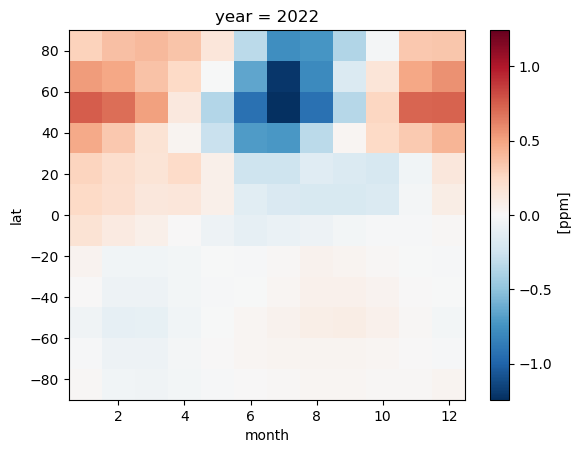

In [32]:
(out["principal-components"] @ out["eofs"]).sel(year=2022).plot()  # type: ignore

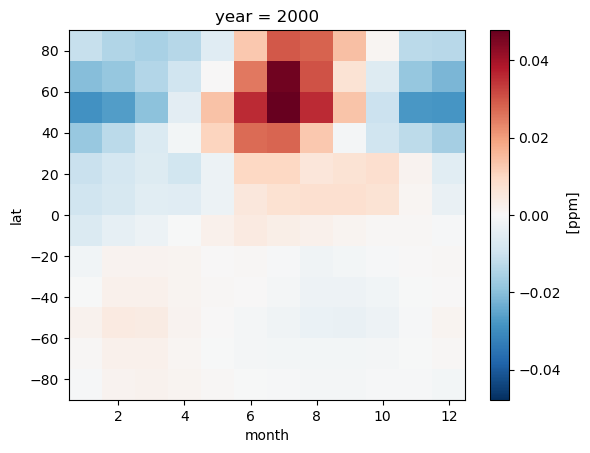

In [33]:
(out["principal-components"] @ out["eofs"]).sel(year=2000).plot()  # type: ignore

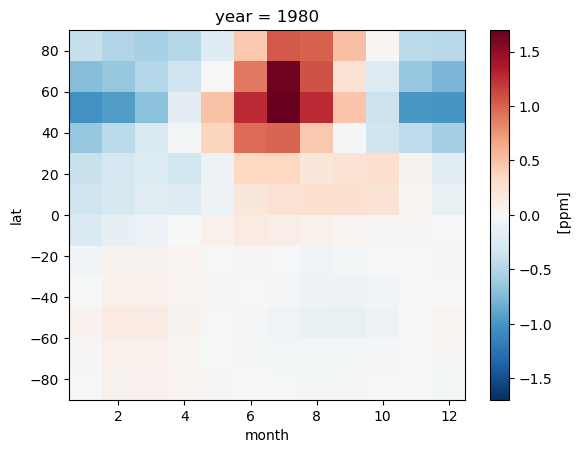

In [34]:
(out["principal-components"] @ out["eofs"]).sel(year=1980).plot()  # type: ignore

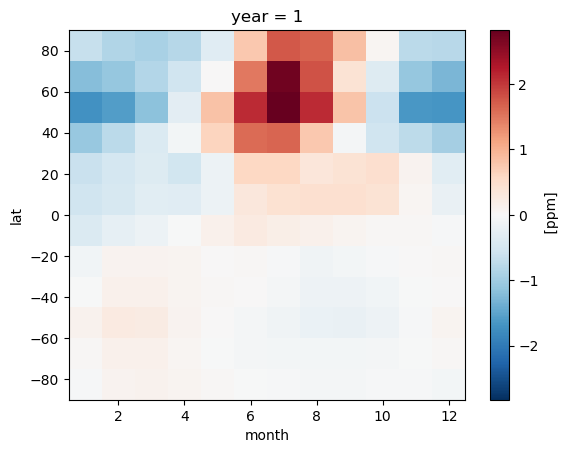

In [35]:
(out["principal-components"] @ out["eofs"]).sel(year=out["year"].min()).plot()  # type: ignore

Quick check that our output matches the observational network in the years they overlap.

In [36]:
xr.testing.assert_allclose(
    (out["principal-components"] @ out["eofs"]).sel(year=seasonality_change_eofs_obs_network["year"]),
    seasonality_change_eofs_obs_network["principal-components"] @ seasonality_change_eofs_obs_network["eofs"],
)

## Save

In [37]:
config_step.seasonality_change_allyears_pcs_eofs_file.parent.mkdir(exist_ok=True, parents=True)
out.pint.dequantify().to_netcdf(config_step.seasonality_change_allyears_pcs_eofs_file)
out

Magnitude,[[-8.775592536994738 -8.775592536994738 -8.775592536994738 ... 2.528839946309975 3.858921499441288 4.054042245710685]]
Units,dimensionless
Magnitude,[[[0.004200787188956484 -0.010149144448462287 -0.014555453750241702 -0.008518519591661078 -0.0038084449949983556 0.0015516709807955693 0.004011410852796488 0.0066049569161054575 0.005455775550594557 0.0038370153756936832 0.0033217633604819647 0.008048412087736516] [-0.003813357863191492 -0.015736342919797267 -0.015416438932829193 -0.005512150461818064 0.0009368741028855893 0.00705632623009416 0.008231968943754596 0.009378428237683771 0.009218433325127137 0.007131926377056381 0.0018463456642353385 -0.0033217612048648563] [-0.012723183583927041 -0.030015453578080133 -0.025684332296317548 -0.010315371668997242 -0.0010074966620193422 0.006882223122370703 0.014211362092602584 0.0224188240780778 0.02351006597529157 0.016888995867390837 0.0038743764884393277 -0.008039811397586055] [0.0007370490716892465 -0.017597452288442225 -0.017063251360386757 -0.008991960486357215 -0.0029845085335313756 -0.0004626650506136561 0.005225324365946439 0.015214897787388758 0.01524183703627152 0.010665375777428774 0.0015370492034393617 -0.0015215101589910343] [0.010202266632504361 -0.010800206632082886 -0.011558184180062644 -0.009210205947219038 -0.0023528224597277017 -0.0026438218443953993 0.003944670545643293 0.01317870486958088 0.009456188015833733 0.004239353692484787 -0.0006499210507010432 -0.0038059335666004632] [0.04632553482317954 0.029488708054586275 0.019598313416887354 0.0007800413398017221 -0.015780861148305857 -0.02827428598026653 -0.022279935844817786 -0.016011011224883038 -0.008984280409509379 -0.004651575425084061 -0.0038102239025934606 0.0035995881363072913] [0.06379741041969815 0.05501880493276163 0.03734811895557013 0.04020622369694015 0.017795935549551542 -0.03562162969243313 -0.04915813014876787 -0.05039283339862896 -0.052481887009473024 -0.04549763894918835 -0.005728793389079505 0.024714516303831785] [0.07118287403135662 0.05553116323103778 0.04325891524130703 0.061617883372439196 0.018217594479479637 -0.06659171813188253 -0.06722738551795744 -0.039863080089778985 -0.046812891968343665 -0.052948030697668624 -0.012462701937959004 0.036097486156288966] [0.12182513963346352 0.08762936319869978 0.04658080791152114 0.009308694648401507 -0.07275208290404085 -0.1832926733709645 -0.18830284107327025 -0.08556203131462699 0.006848925088064385 0.0648089153715204 0.08444451622328954 0.10846341823053145] [0.1961220169695092 0.17977863424293714 0.13308041965230769 0.03377719450459981 -0.0936991937878084 -0.24096428211757012 -0.32187345139180995 -0.24063146122865528 -0.09263687482193474 0.07032097856082614 0.18665744724296696 0.19006862406736472] [0.1359161249571294 0.1241778144862185 0.09536034021346418 0.06514735951345428 -0.0018692306765028452 -0.1702972354581949 -0.31252810445932316 -0.20595301434906468 -0.045313307251242683 0.04274468124382565 0.12457144699702265 0.14804339012981396] [0.07357219576595192 0.09634071762514099 0.10374128219273218 0.09284978310532996 0.038141070984567926 -0.08568009369276812 -0.20029543562732988 -0.19107522886994588 -0.09787247237255348 -0.005934616002685327 0.08694702678150247 0.08926615886618836]]]
Units,ppm


In [38]:
config_step.seasonality_change_temperature_co2_conc_regression_file.parent.mkdir(exist_ok=True, parents=True)
with open(config_step.seasonality_change_temperature_co2_conc_regression_file, "w") as fh:
    fh.write(local.config.converter_yaml.dumps(regressor_incl_result))

regressor_incl_result

CO2SeasonalityChangeRegression(ref_period_start=1850, ref_period_end=1880, norm_period_start=2000, norm_period_end=2010, temperature_smoothing_window=15, temperature_smoothing_min_values=5, regression_result=LinearRegressionResult(m=<Quantity(9.076883630347558, 'dimensionless')>, c=<Quantity(-8.78663711284472, 'dimensionless')>))

In [39]:
config_step.seasonality_change_temperature_co2_conc_regression_file

PosixPath('/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/data/interim/co2/co2_seasonality-change_temp-conc-regression.yaml')